In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
# PARAMETERS
N = 64
numSamples = 20000

X_data = np.zeros((numSamples, 2*N))
Y_data = np.zeros((numSamples, 2*N))

for i in range(numSamples):

    # CHANNEL
    L = 8
    pdp = np.exp(-np.arange(L)/2)
    pdp = pdp / np.sum(pdp)

    h = (np.random.randn(L) + 1j*np.random.randn(L)) * np.sqrt(pdp/2)

    H_true = np.fft.fft(np.concatenate([h, np.zeros(N-L)]))

    # LS (noisy version)
    noise = 0.1 * (np.random.randn(N) + 1j*np.random.randn(N))
    H_LS = H_true + noise

    # STORE (real + imag)
    X_data[i,:] = np.concatenate([np.real(H_LS), np.imag(H_LS)])
    Y_data[i,:] = np.concatenate([np.real(H_true), np.imag(H_true)])

print("Dataset created:", X_data.shape)

Dataset created: (20000, 128)


In [4]:
# Split
train_size = int(0.8 * len(X_data))

X_train = X_data[:train_size]
Y_train = Y_data[:train_size]

X_val = X_data[train_size:]
Y_val = Y_data[train_size:]

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)

Train size: (16000, 128)
Validation size: (4000, 128)


In [5]:
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(128,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-17 13:01:07.290874: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,712 (514.50 KB)

 Trainable params: 131,712 (514.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=30,
    batch_size=64,
    verbose=1
)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1292 - val_loss: 0.0076
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0067 - val_loss: 0.0052
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0047 - val_loss: 0.0039
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0039 - val_loss: 0.0035
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0033 - val_loss: 0.0031
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0029 - val_loss: 0.0028
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0027 - val_loss: 0.0028
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0026 - val_loss: 0.0024
Epoch 9/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0024 - val_loss: 0.0027
Epoch 10/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 11/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 12/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

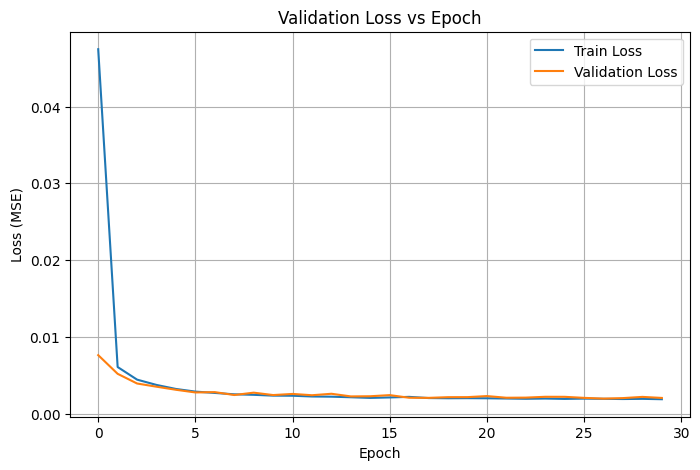

In [7]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Validation Loss vs Epoch')
plt.legend()
plt.grid()

plt.show()

In [8]:
model.save("/kaggle/working/dnn_channel_model.h5")

In [10]:
W1, b1 = model.layers[0].get_weights()
W2, b2 = model.layers[1].get_weights()
W3, b3 = model.layers[2].get_weights()

np.save('/kaggle/working/W1.npy', W1)
np.save('/kaggle/working/b1.npy', b1)

np.save('/kaggle/working/W2.npy', W2)
np.save('/kaggle/working/b2.npy', b2)

np.save('/kaggle/working/W3.npy', W3)
np.save('/kaggle/working/b3.npy', b3)